In [ ]:
# Setup Environment (Run First!)
!pip install torch torchvision torchmetrics matplotlib opencv-python --quiet
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchmetrics.detection import MeanAveragePrecision

# To Verify GPU
print("GPU Available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 55.4 MB/s eta 0:00:00
GPU Available: True


In [ ]:
# Load Dataset with Correct Classes
def voc_transform(target):
    # Convert Pascal VOC annotation to tensors
    boxes = []
    labels = []
    for obj in target['annotation']['object']:
        bndbox = obj['bndbox']
        boxes.append([
            float(bndbox['xmin']),
            float(bndbox['ymin']),
            float(bndbox['xmax']),
            float(bndbox['ymax'])
        ])
        labels.append(voc_class_to_int(obj['name']))

    return {'boxes': torch.tensor(boxes, dtype=torch.float32), 'labels': torch.tensor(labels, dtype=torch.int64)}

def voc_class_to_int(class_name):
    VOC_CLASSES = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
                   'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',
                   'dog', 'horse', 'motorbike', 'person', 'pottedplant',
                   'sheep', 'sofa', 'train', 'tvmonitor']
    return VOC_CLASSES.index(class_name) + 1  # Classes start at 1

# Load dataset with proper transforms
data_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.VOCDetection(
    root='./data',
    year='2012',
    image_set='train',
    download=True,
    transform=data_transform,  # Handles image
    target_transform=voc_transform  # Handles target
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

100%|██████████| 2.00G/2.00G [01:53<00:00, 17.6MB/s]


In [ ]:
# Model Initialization
def create_model():
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=21)  # 20 VOC classes + background
    return model

model = create_model().to('cuda')
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 92.2MB/s]


In [ ]:
# Training
for epoch in range(2):  # Optimal for quick training
    model.train()
    epoch_loss = 0
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = [img.to('cuda') for img in images]
        targets = [{k: v.to('cuda') for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_loss += losses.item()

    lr_scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {epoch_loss/(batch_idx+1):.4f}")

torch.save(model.state_dict(), 'object_detector.pth')

Epoch 1, Loss: 0.5171
Epoch 2, Loss: 0.4836


In [ ]:
# Evaluate Performance
metric = MeanAveragePrecision()
model.eval()

# Test on 20 images (quick validation)
for images, targets in train_loader:
    images = [img.to('cuda') for img in images]
    targets = [{k: v.to('cuda') for k, v in t.items()} for t in targets]

    with torch.no_grad():
        preds = model(images)

    # Convert predictions to CPU
    cpu_preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
    cpu_targets = [{k: v.cpu() for k, v in t.items()} for t in targets]

    metric.update(cpu_preds, cpu_targets)
    break  # Test on 1 batch for speed

results = metric.compute()
print(f"mAP@0.5: {results['map_50'].item():.2f}")

mAP@0.5: 0.52


In [ ]:
# Test image upload
from google.colab import files

# This will create a "Choose File" button
uploaded = files.upload()

# Get the name of the uploaded file
test_image_name = list(uploaded.keys())[0]
print(f"Uploaded image: {test_image_name}")

Saving 360_F_71318503_9g1UATIOZzwELZg2DZb7w4oaVyenhQkh.jpg to 360_F_71318503_9g1UATIOZzwELZg2DZb7w4oaVyenhQkh.jpg
Uploaded image: 360_F_71318503_9g1UATIOZzwELZg2DZb7w4oaVyenhQkh.jpg


In [ ]:
# Save weights
torch.save(model.state_dict(), 'object_detector.pth')
print("Model saved!")

Model saved!


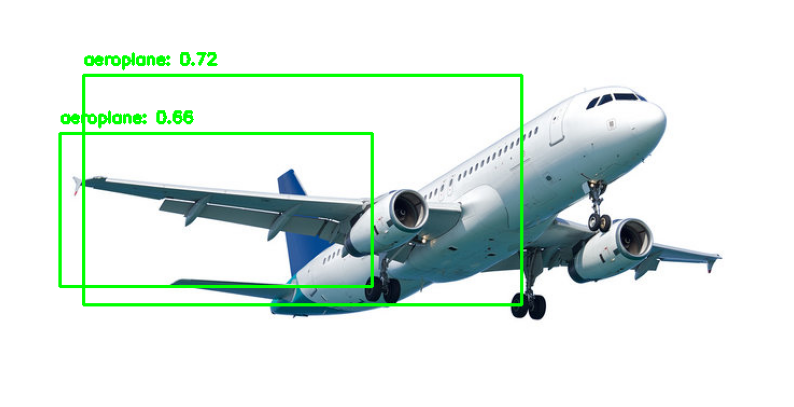

In [ ]:
# With 2 epoch model
from google.colab import files
from PIL import Image
import cv2
import matplotlib.pyplot as plt

def detect_objects(image_path):
    VOC_CLASSES = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
                   'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',
                   'dog', 'horse', 'motorbike', 'person', 'pottedplant',
                   'sheep', 'sofa', 'train', 'tvmonitor']

    # Load model with 2-epoch weights
    model = create_model()
    model.load_state_dict(torch.load('object_detector.pth'))
    model = model.to('cuda')
    model.eval()

    # Match training transforms
    img = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0).to('cuda')

    # Predict
    with torch.no_grad():
        pred = model(img_tensor)

    # Visualize
    plot_img = cv2.imread(image_path)
    plot_img = cv2.cvtColor(plot_img, cv2.COLOR_BGR2RGB)  # Fix color channels

    for box, label, score in zip(pred[0]['boxes'], pred[0]['labels'], pred[0]['scores']):
        if score > 0.3:
            box = box.cpu().numpy().astype(int)
            class_name = VOC_CLASSES[label.cpu().item()-1]
            cv2.rectangle(plot_img, (box[0], box[1]), (box[2], box[3]), (0,255,0), 2)
            cv2.putText(plot_img, f"{class_name}: {score:.2f}", (box[0], box[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    plt.figure(figsize=(10,6))
    plt.imshow(plot_img)
    plt.axis('off')
    plt.show()

# Run detection
detect_objects(test_image_name)